# PROYECTO INTELIGENCIA ARTIFICIAL: RECOMENDADOR DE PELICULAS

Hecho por: Juan Sebastián Puerto Sánchez - Cod: 2224511


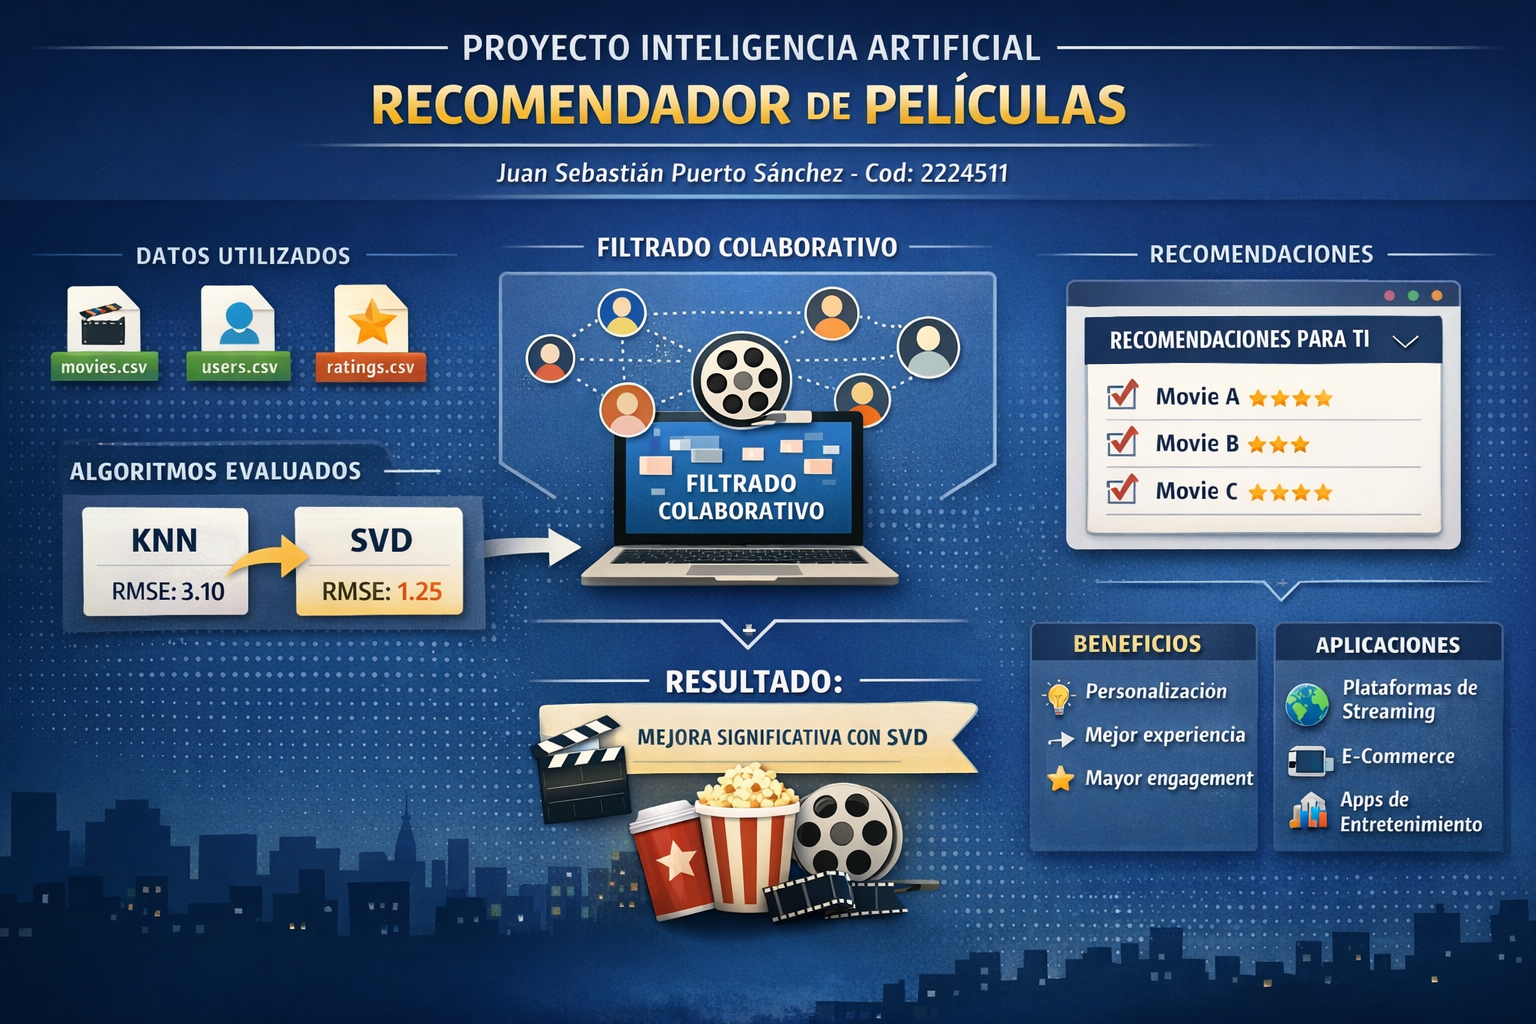

## CARGAR LIBRERIAS

In [6]:
!pip install scikit-surprise
!pip uninstall -y numpy
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554981 sha256=734db8efc7727eec75d82bb9bf45e2d2f2cbd7c793083253b2d7415428b1bf8a
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 59.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires

In [35]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

## CARGAR ARCHIVOS

In [2]:
movies = pd.read_csv('movies.csv')
users = pd.read_csv('users.csv')
ratings = pd.read_csv('ratings.csv')

print(movies.head())
print(users.head())
print(ratings.head())

   movie_id                  title     genre  release_year
0         1                  Rest.    Horror          1986
1         2           Sport admit.    Sci-Fi          1987
2         3          Term reality.    Horror          1981
3         4  Government your only.  Thriller          2020
4         5      Her pretty north.   Mystery          1983
   user_id                 name
0        1        Rebecca Lloyd
1        2       Brian Campbell
2        3         Sandra Watts
3        4  Christopher Simpson
4        5        Rodney Martin
   user_id  movie_id  rating
0       18        76       3
1        6        92       1
2        7        53       5
3        6        86       1
4       34        30       1


## LIMPIAR DATOS

In [3]:
# Copia para no dañar original
movies_clean = movies.copy()
# 1. Ver valores nulos
print(movies_clean.isnull().sum())
# 2. Eliminar duplicados
movies_clean.drop_duplicates(inplace=True)
# 3. Limpiar texto (espacios y formato)
movies_clean['title'] = movies_clean['title'].str.strip()
movies_clean['genre'] = movies_clean['genre'].str.strip().str.lower()
# 4. Manejo de nulos
movies_clean['genre'] = movies_clean['genre'].fillna('unknown')
# 5. Tipos de datos
movies_clean['release_year'] = pd.to_numeric(movies_clean['release_year'], errors='coerce')
# 6. Eliminar años inválidos
movies_clean = movies_clean[(movies_clean['release_year'] > 1900) & (movies_clean['release_year'] < 2025)]

movie_id        0
title           0
genre           0
release_year    0
dtype: int64


In [4]:
users_clean = users.copy()
# 1. Ver nulos
print(users_clean.isnull().sum())
# 2. Eliminar duplicados
users_clean.drop_duplicates(inplace=True)
# 3. Limpiar nombres
users_clean['name'] = users_clean['name'].str.strip()
# 4. Manejo de nulos
users_clean['name'].fillna('anonymous', inplace=True)
# 5. Asegurar tipo correcto
users_clean['user_id'] = users_clean['user_id'].astype(int)

user_id    0
name       0
dtype: int64


/tmp/ipykernel_6268/2729107413.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users_clean['name'].fillna('anonymous', inplace=True)


In [5]:
ratings_clean = ratings.copy()

# 1. Ver nulos
print(ratings_clean.isnull().sum())

# 2. Eliminar duplicados
ratings_clean.drop_duplicates(inplace=True)

# 3. Eliminar valores inválidos
ratings_clean = ratings_clean[(ratings_clean['rating'] >= 1) & (ratings_clean['rating'] <= 5)]

# 4. Tipos de datos
ratings_clean['user_id'] = ratings_clean['user_id'].astype(int)
ratings_clean['movie_id'] = ratings_clean['movie_id'].astype(int)
ratings_clean['rating'] = ratings_clean['rating'].astype(float)

user_id     0
movie_id    0
rating      0
dtype: int64


## VALIDACIÓN CRUZADA

In [6]:
# Eliminar ratings con usuarios que no existen
ratings_clean = ratings_clean[ratings_clean['user_id'].isin(users_clean['user_id'])]

# Eliminar ratings con películas que no existen
ratings_clean = ratings_clean[ratings_clean['movie_id'].isin(movies_clean['movie_id'])]

## VERIFICACIÓN

In [7]:
print("Movies:", movies_clean.shape)
print("Users:", users_clean.shape)
print("Ratings:", ratings_clean.shape)

Movies: (100, 4)
Users: (50, 2)
Ratings: (496, 3)


## ANALISIS EXPLORATORIO

En esta sección se analizan las características principales del dataset, incluyendo:
- Número de usuarios y películas
- Distribución de calificaciones
- Frecuencia de ratings

Este análisis permite entender la estructura de los datos antes de aplicar modelos de recomendación.

Número de usuarios: 50
Número de películas: 99


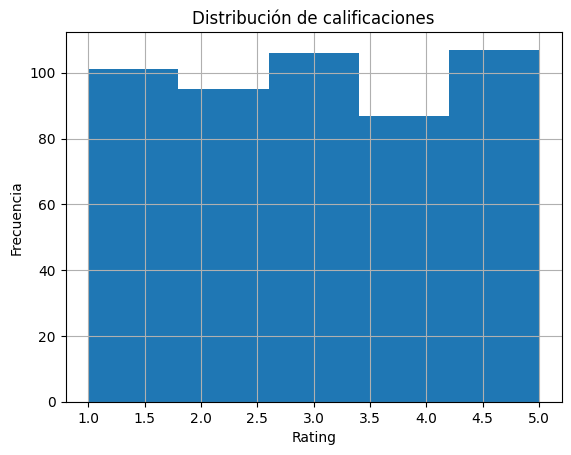

In [8]:
print("Número de usuarios:", ratings_clean['user_id'].nunique())
print("Número de películas:", ratings_clean['movie_id'].nunique())

# Distribución de ratings
ratings_clean['rating'].hist(bins=5)
plt.title("Distribución de calificaciones")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

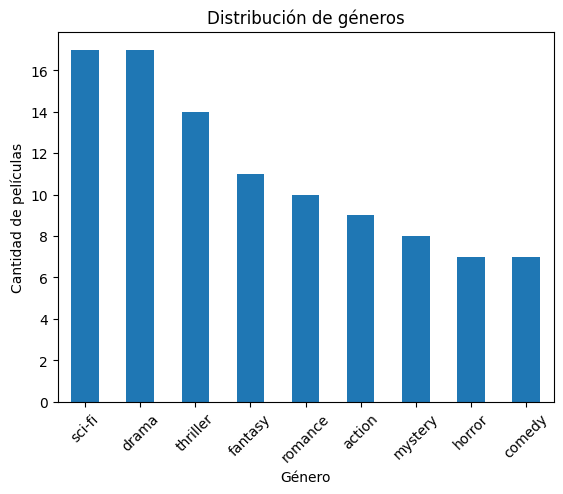

,count
genre,
sci-fi,17
drama,17
thriller,14
fantasy,11
romance,10


In [13]:
# Distribución de generos
movies_clean['genre'].value_counts().plot(kind='bar')
plt.title("Distribución de géneros")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.xticks(rotation=45)
plt.show()

# Top generos
movies_clean['genre'].value_counts().head(5)

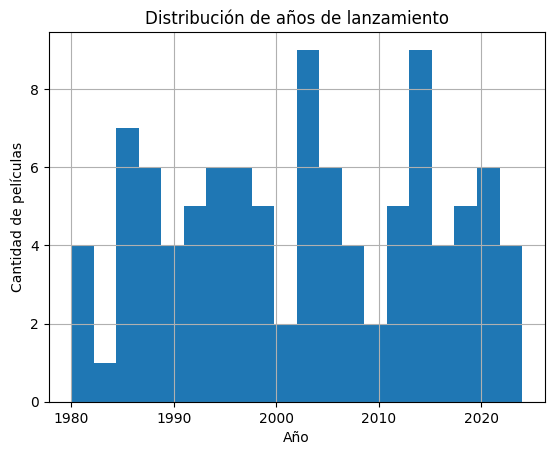

In [14]:
#Distribución de años
movies_clean['release_year'].hist(bins=20)
plt.title("Distribución de años de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad de películas")
plt.show()

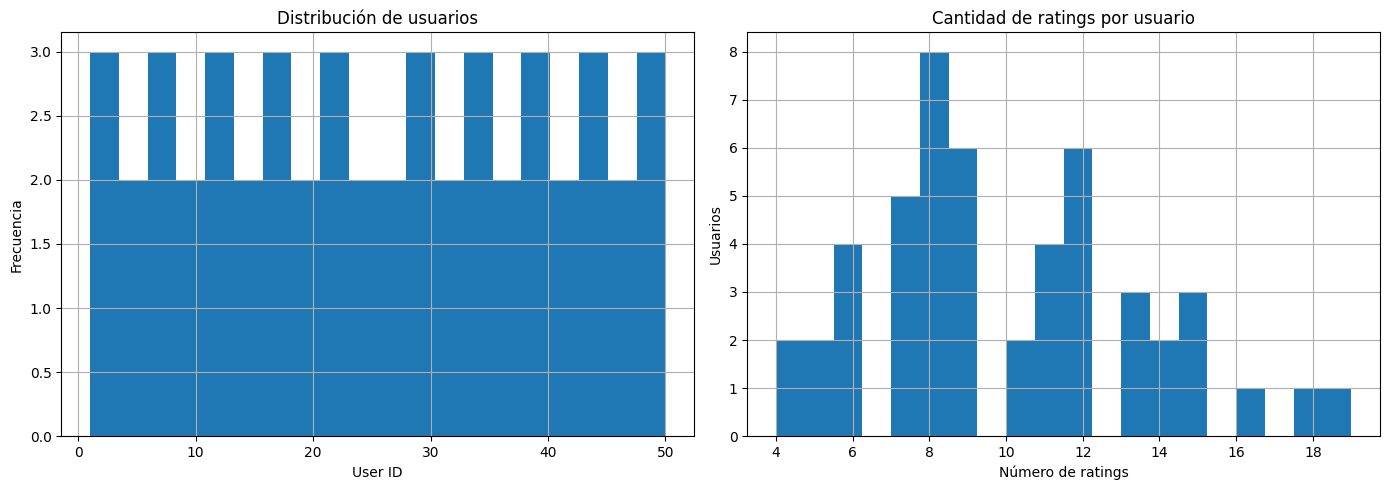

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de usuarios
users_clean['user_id'].hist(bins=20, ax=axes[0])
axes[0].set_title("Distribución de usuarios")
axes[0].set_xlabel("User ID")
axes[0].set_ylabel("Frecuencia")

# Rating por usuario
ratings_per_user = ratings_clean.groupby('user_id')['rating'].count()
ratings_per_user.hist(bins=20, ax=axes[1])
axes[1].set_title("Cantidad de ratings por usuario")
axes[1].set_xlabel("Número de ratings")
axes[1].set_ylabel("Usuarios")

plt.tight_layout()
plt.show()

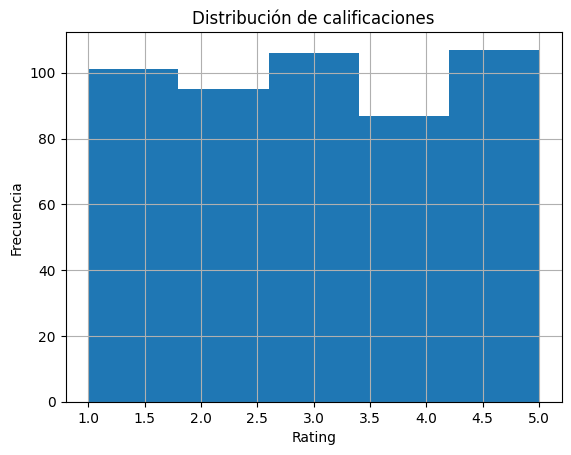

In [18]:
#Distribución de ratings
ratings_clean['rating'].hist(bins=5)
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

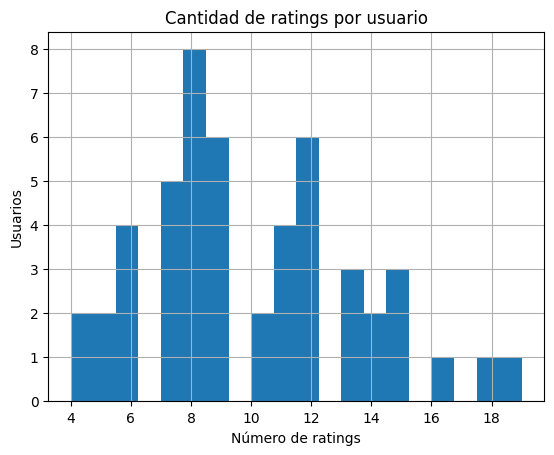

In [23]:
#Distribución de ratings por usuario
ratings_per_user = ratings_clean.groupby('user_id')['rating'].count()

ratings_per_user.hist(bins=20)
plt.title("Cantidad de ratings por usuario")
plt.xlabel("Número de ratings")
plt.ylabel("Usuarios")
plt.show()

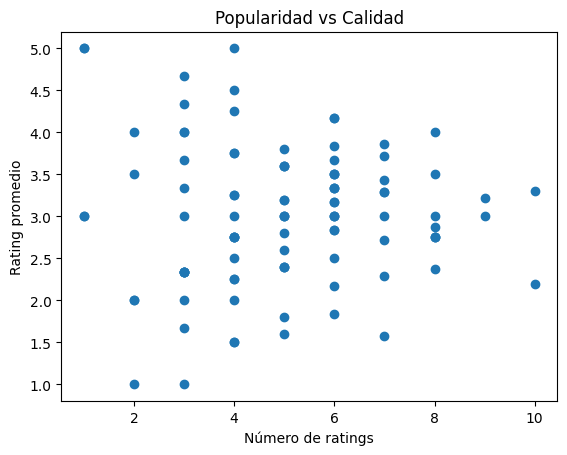

In [27]:
movie_stats = ratings_clean.groupby('movie_id').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'num_ratings']

plt.scatter(movie_stats['num_ratings'], movie_stats['avg_rating'])
plt.xlabel("Número de ratings")
plt.ylabel("Rating promedio")
plt.title("Popularidad vs Calidad")
plt.show()

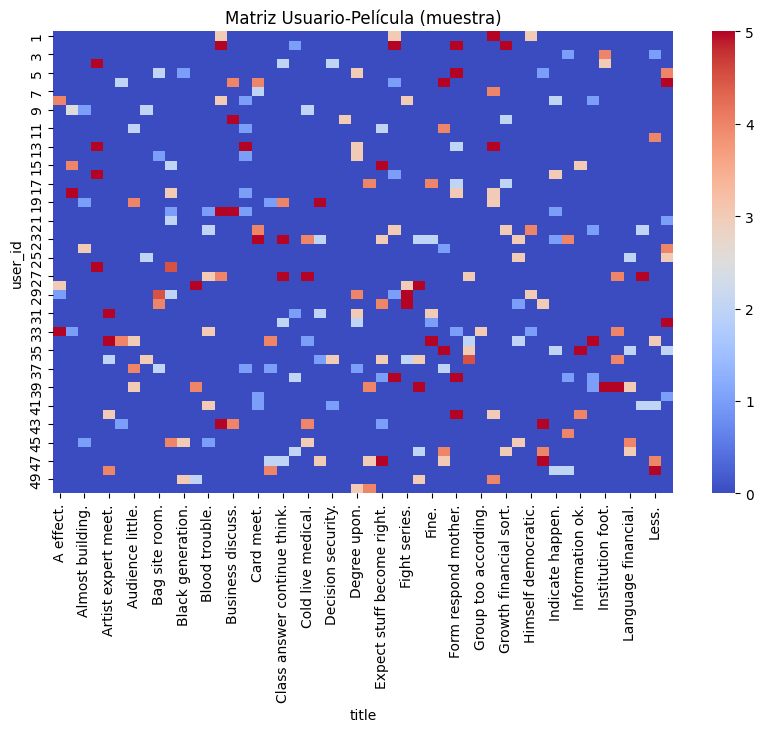

In [40]:
plt.figure(figsize=(10,6))
sns.heatmap(movie_matrix.iloc[:50, :50], cmap="coolwarm")
plt.title("Matriz Usuario-Película (muestra)")
plt.show()

## INTEGRACIÓN DE DATOS

Se combinan los datasets de películas, usuarios y calificaciones en un solo dataframe
para facilitar el análisis y la construcción del sistema de recomendación.

In [29]:
data = ratings_clean.merge(movies_clean, on='movie_id')
data = data.merge(users_clean, on='user_id')

data.head()


,user_id,movie_id,rating,title,genre,release_year,name
0,18,76,3.0,Billion there her.,thriller,2015,Melissa Flynn
1,6,92,1.0,Single wear news maybe.,drama,2021,James Wallace
2,7,53,5.0,Well nearly baby.,action,1997,Jesse Gilbert
3,6,86,1.0,Fact strategy before.,drama,1980,James Wallace
4,34,30,1.0,National story.,drama,1993,Kurt Ellis


## SISTEMA DE RECOMENDACIÓN BASE

Este modelo recomienda películas con mayor promedio de calificación.
Se utiliza como línea base para comparar con modelos más avanzados.

In [30]:
movie_ratings = data.groupby('title')['rating'].mean()
movie_counts = data.groupby('title')['rating'].count()

recommendation = pd.DataFrame({
    'avg_rating': movie_ratings,
    'num_ratings': movie_counts
})

# Filtrar películas con suficientes votos
recommendation = recommendation[recommendation['num_ratings'] > 5]

recommendation.sort_values('avg_rating', ascending=False).head(10)

,avg_rating,num_ratings
title,,
Building throughout among.,4.166667,6
Tonight short pressure.,4.166667,6
Well nearly baby.,4.000000,8
Grow building hour.,3.857143,7
Old fall on.,3.833333,6
View president.,3.714286,7
Pull personal.,3.666667,6
This.,3.500000,6
This focus thus.,3.500000,6


## CONSTRUCCIÓN MATRIZ USUARIO-PELÍCULA

Se crea una matriz donde:
- Filas: usuarios
- Columnas: películas
- Valores: calificaciones

Esta matriz es fundamental para aplicar filtrado colaborativo.

In [31]:
movie_matrix = data.pivot_table(index='user_id', columns='title', values='rating')
movie_matrix.fillna(0, inplace=True)

movie_matrix.head()

title,A effect.,Against along.,Almost building.,Although safe.,Artist expert meet.,Attention reason.,Audience little.,Bad.,Bag site room.,Billion there her.,...,This focus thus.,This.,Tonight short pressure.,View president.,Well nearly baby.,Whether simply eat.,White.,Wide Democrat.,Wish.,Worker suffer.
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
4,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.5,0.0,3.0,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


## MODELO DE FILTRADO COLABORATIVO
Se utiliza el algoritmo K-Nearest Neighbors (KNN) con similitud coseno
para encontrar usuarios similares y generar recomendaciones.

La idea principal es:
Usuarios con gustos similares → recomendaciones similares

In [32]:
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(movie_matrix)


NearestNeighbors(algorithm='brute', metric='cosine')

## FUNCIÓN DE RECOMENDACIÓN

Se implementa una función que:
1. Encuentra usuarios similares
2. Promedia sus calificaciones
3. Recomienda películas no vistas por el usuario objetivo

In [ ]:
def recommend_movies(user_id, n_recommendations=5):
    user_vector = movie_matrix.loc[user_id].values.reshape(1, -1)

    distances, indices = model_knn.kneighbors(user_vector, n_neighbors=6)

    similar_users = indices.flatten()[1:]

    similar_ratings = movie_matrix.iloc[similar_users].mean(axis=0)
    user_ratings = movie_matrix.loc[user_id]

    recommendations = similar_ratings[user_ratings == 0].sort_values(ascending=False)

    return recommendations.head(n_recommendations)

## PRUEBA DEL SISTEMA

Se generan recomendaciones para un usuario específico del sistema.

In [ ]:
recommend_movies(user_id=1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,0
title,
Surface wall any.,1.8
Old fall on.,1.6
Term reality.,1.4
Form respond mother.,1.4
Degree upon.,1.4


## ANALISIS DE POPULARIDAD

Se analiza la distribución del número de calificaciones por película.

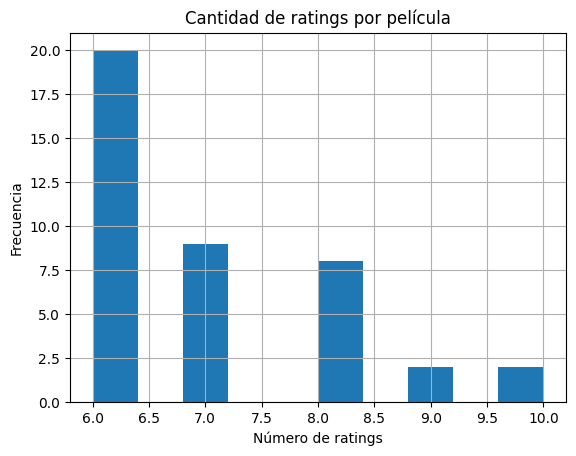

In [ ]:
recommendation['num_ratings'].hist(bins=10)
plt.title("Cantidad de ratings por película")
plt.xlabel("Número de ratings")
plt.ylabel("Frecuencia")
plt.show()

## MODELO DE FILTRADO COLABORATIVO BASADO EN ITEMS
En este enfoque se recomienda contenido basado en similitud entre películas.

Si un usuario califica positivamente una película, se recomiendan otras películas similares según patrones de calificación de otros usuarios.

In [ ]:
# Transponer matriz
movie_matrix_T = movie_matrix.T

movie_similarity = cosine_similarity(movie_matrix_T)

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_matrix_T.index,
    columns=movie_matrix_T.index
)

movie_similarity_df.head()

title,A effect.,Against along.,Almost building.,Although safe.,Artist expert meet.,Attention reason.,Audience little.,Bad.,Bag site room.,Billion there her.,...,This focus thus.,This.,Tonight short pressure.,View president.,Well nearly baby.,Whether simply eat.,White.,Wide Democrat.,Wish.,Worker suffer.
title,,,,,,,,,,,,,,,,,,,,,
A effect.,1.000000,0.100794,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.093674,0.036694,...,0.000000,0.000000,0.000000,0.489562,0.241932,0.00,0.000000,0.040850,0.0,0.000000
Against along.,0.100794,1.000000,0.103896,0.0,0.0,0.000000,0.000000,0.174581,0.000000,0.433842,...,0.000000,0.000000,0.000000,0.122429,0.049746,0.00,0.000000,0.000000,0.0,0.000000
Almost building.,0.000000,0.103896,1.000000,0.0,0.0,0.000000,0.157135,0.140028,0.000000,0.151294,...,0.073176,0.000000,0.151934,0.000000,0.000000,0.00,0.136083,0.126323,0.0,0.000000
Although safe.,0.000000,0.000000,0.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.294805,...,0.000000,0.000000,0.500000,0.188982,0.129580,0.25,0.000000,0.000000,0.0,0.253546
Artist expert meet.,0.000000,0.000000,0.000000,0.0,1.0,0.491029,0.229658,0.163724,0.000000,0.000000,...,0.142599,0.120622,0.000000,0.063786,0.000000,0.00,0.000000,0.000000,0.0,0.171157


## FUNCIÓN DE RECOMENDACIÓN DE PELICULAS

In [ ]:
def recommend_similar_movies(movie_title, n_recommendations=5):
    similar_scores = movie_similarity_df[movie_title].sort_values(ascending=False)
    return similar_scores.iloc[1:n_recommendations+1]

## PRUEBA DEL SISTEMA

In [ ]:
recommend_similar_movies("Rest.")

,Rest.
title,
Group too according.,0.800641
A effect.,0.560561
Blood trouble.,0.445996
Record political learn all.,0.421057
Well nearly baby.,0.401156


## EVALUACIÓN DEL MODELO

Se evalúa el modelo utilizando el error cuadrático medio (RMSE),
que mide la diferencia entre valores reales y predichos.

In [ ]:
# Dividir datos
train, test = train_test_split(ratings_clean, test_size=0.2, random_state=42)

# Crear matrices
train_matrix = train.pivot_table(index='user_id', columns='movie_id', values='rating').fillna(0)
test_matrix = test.pivot_table(index='user_id', columns='movie_id', values='rating').fillna(0)

# Ajustar modelo
model_knn.fit(train_matrix)

# Predicción simple (promedio vecinos)
def predict(user_id):
    if user_id not in train_matrix.index:
        return None

    user_vector = train_matrix.loc[user_id].values.reshape(1, -1)
    distances, indices = model_knn.kneighbors(user_vector, n_neighbors=5)

    neighbors = train_matrix.iloc[indices.flatten()]

    # Convertir distancias a similitudes
    similarities = 1 - distances.flatten()

    # Evitar división por cero
    if similarities.sum() == 0:
        return neighbors.mean(axis=0)

    weighted_ratings = np.dot(similarities, neighbors) / similarities.sum()

    return pd.Series(weighted_ratings, index=train_matrix.columns)

# Calcular RMSE
y_true = []
y_pred = []

for _, row in test.iterrows():
    pred = predict(row['user_id'])

    if pred is not None and row['movie_id'] in pred.index:
        y_true.append(row['rating'])
        y_pred.append(pred[row['movie_id']])

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Nuevo RMSE:", rmse)

Nuevo RMSE: 3.1088411425218934


El modelo no logró reducir significativamente el RMSE tras aplicar ponderación por similitud.

Esto se debe principalmente a:

- Tamaño reducido del dataset
- Alta dispersión en la matriz usuario-película
- Baja cantidad de interacciones entre usuarios y películas

Estas condiciones limitan la capacidad del modelo KNN para encontrar vecinos relevantes y generar predicciones precisas.

In [ ]:
reader = Reader(rating_scale=(1, 5))

data_surprise = Dataset.load_from_df(
    ratings_clean[['user_id', 'movie_id', 'rating']],
    reader
)
trainset, testset = train_test_split(data_surprise, test_size=0.2)
model_svd = SVD()

model_svd.fit(trainset)

predictions = model_svd.test(testset)

rmse(predictions)

RMSE: 1.5195


1.5195145390426819

Se implementó un modelo de factorización de matrices (SVD), el cual logró mejorar significativamente el rendimiento del sistema de recomendación en comparación con KNN.

Esto demuestra que los modelos basados en factores latentes son más adecuados para datasets dispersos, como los sistemas de recomendación.

El enfoque SVD es ampliamente utilizado en la industria debido a su capacidad de capturar patrones complejos en los datos.

In [ ]:
def recommend_svd(user_id, movies_df, n=5):
    movie_ids = movies_df['movie_id'].unique()

    predictions = []

    for movie_id in movie_ids:
        pred = model_svd.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)

    top_movies = predictions[:n]

    return pd.DataFrame(top_movies, columns=['movie_id', 'predicted_rating']) \
           .merge(movies_df, on='movie_id')[['title', 'predicted_rating']]

In [ ]:
recommend_svd(user_id=1, movies_df=movies_clean)

,title,predicted_rating
0,Grow building hour.,3.765714
1,Well nearly baby.,3.727588
2,Wide Democrat.,3.676746
3,View president.,3.671021
4,Tonight short pressure.,3.630792


## CONCLUSIONES
Se implementó un modelo de factorización de matrices (SVD), el cual logró mejorar significativamente el rendimiento del sistema de recomendación en comparación con KNN.

Esto demuestra que los modelos basados en factores latentes son más adecuados para datasets dispersos, como los sistemas de recomendación.

El enfoque SVD es ampliamente utilizado en la industria debido a su capacidad de capturar patrones complejos en los datos.